In [91]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [92]:
def read_file(filename):
    return pd.read_csv(filename)

df = read_file("result.csv")
df = df[df["use_backoff"] == 0]

# df = read_file("result.csv")
# # Filter out rows where thread count is 20 to avoid OS preemption artifacts
# df = df[df["threads"] != 20]


df_with_exponential_backoff = df[df["use_backoff"] == 1]
df = df[df["use_backoff"] == 0]

## When n = 10000

In [93]:
# df_10000 = df #df[df['n'] == 100]
# df_10000.describe()

In [94]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8,6))
# plt.scatter(df_10000['threads'], df_10000['tas_ms'])
# plt.title('Scatter Plot of Threads vs tas_ms (n = 10000)')
# plt.xlabel('Threads')
# plt.ylabel('tas_ms')
# plt.grid(True)
# plt.show()

In [95]:
# # Plot Time vs Threads for each lock type, with separate curves for each outside_work

# import seaborn as sns

# locks = ['tas_ms', 'ttas_ms', 'mcs_ms']
# lock_names = {'tas_ms': 'Test-and-Set', 'ttas_ms': 'Test-and-Test-and-Set', 'mcs_ms': 'MCS'}
# outside_works = sorted(df_10000['outside_work'].unique())

# for lock in locks:
#     plt.figure(figsize=(10,6))
#     for out in outside_works:
#         df_group = df_10000[df_10000['outside_work'] == out]
#         # Sort by threads for clearer lines
#         df_group = df_group.sort_values('threads')
#         plt.plot(df_group['threads'], df_group[lock], marker='o', label=f'OUTSIDE_WORK={out}')
#     plt.title(f'Time vs Threads for {lock_names[lock]} Lock\n(n = 10000)')
#     plt.xlabel('Threads')
#     plt.ylabel('Time (ms)')
#     plt.legend(title='OUTSIDE_WORK')
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

### Analyze PERFORMANCE among locking mechanism

#### Heat map on average execution time

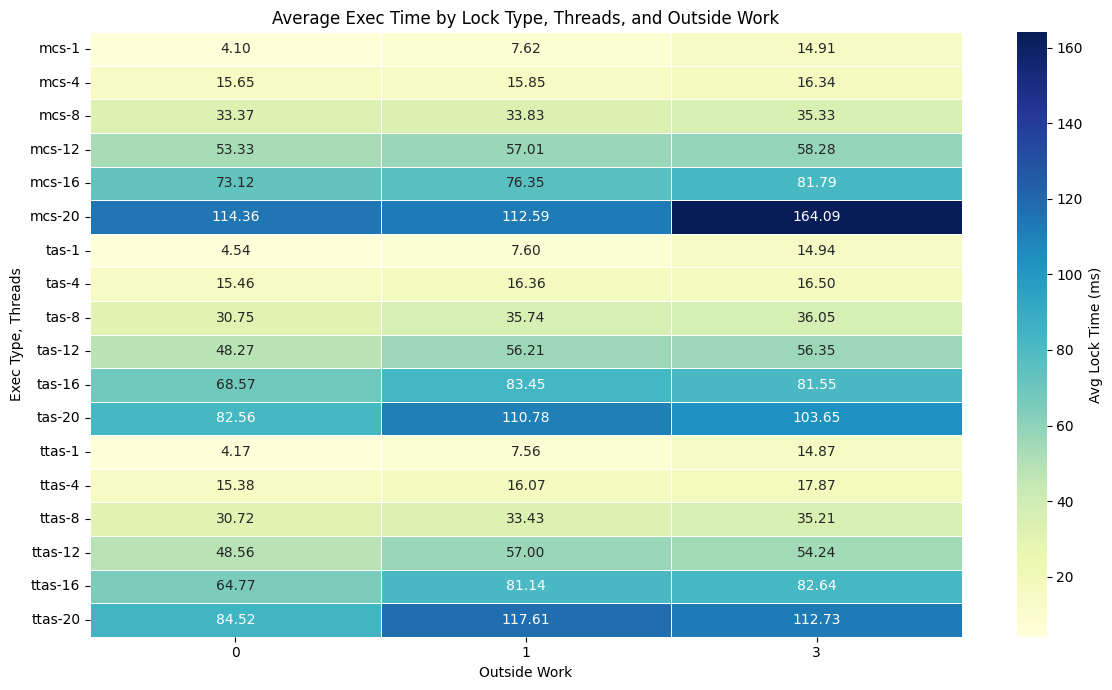

In [96]:


# Prepare 'lock', 'time' format for easier analysis, then concatenate for all lock types
frames = []
for lock in ['tas_ms', 'ttas_ms', 'mcs_ms']:
    df_tmp = df[['threads', 'outside_work', lock]].copy()
    df_tmp = df_tmp.rename(columns={lock: 'time'})
    df_tmp['lock'] = lock.replace('_ms', '')
    frames.append(df_tmp)

df_long = pd.concat(frames, ignore_index=True)

# Calculate min, median, max, avg by lock and threads (for small contention)
min_time = df_long.groupby(['lock', 'threads'])['time'].min()
median_time = df_long.groupby(['lock', 'threads'])['time'].median()
max_time = df_long.groupby(['lock', 'threads'])['time'].max()
avg_time = df_long.groupby(['lock', 'threads'])['time'].mean()

# Present as DataFrame for easier inspection:
stats_df = pd.DataFrame({
    'min': min_time,
    'median': median_time,
    'max': max_time,
    'avg': avg_time
}).reset_index()

# display(stats_df)

# Create a pivot table: rows=(lock,threads), columns=outside_work, values=time (avg)
pivot_table = pd.pivot_table(
    df_long, 
    values='time',
    index=['lock', 'threads'],
    columns=['outside_work'],
    aggfunc='mean'
)

# show chart

plt.figure(figsize=(12, 7))
sns.heatmap(
    pivot_table, 
    annot=True, 
    fmt=".2f", 
    cmap="YlGnBu", 
    linewidths=.5, 
    cbar_kws={'label': 'Avg Lock Time (ms)'}
)
plt.title('Average Exec Time by Lock Type, Threads, and Outside Work')
plt.ylabel('Exec Type, Threads')
plt.xlabel('Outside Work')
plt.tight_layout()
plt.show()




#### Cost of lock

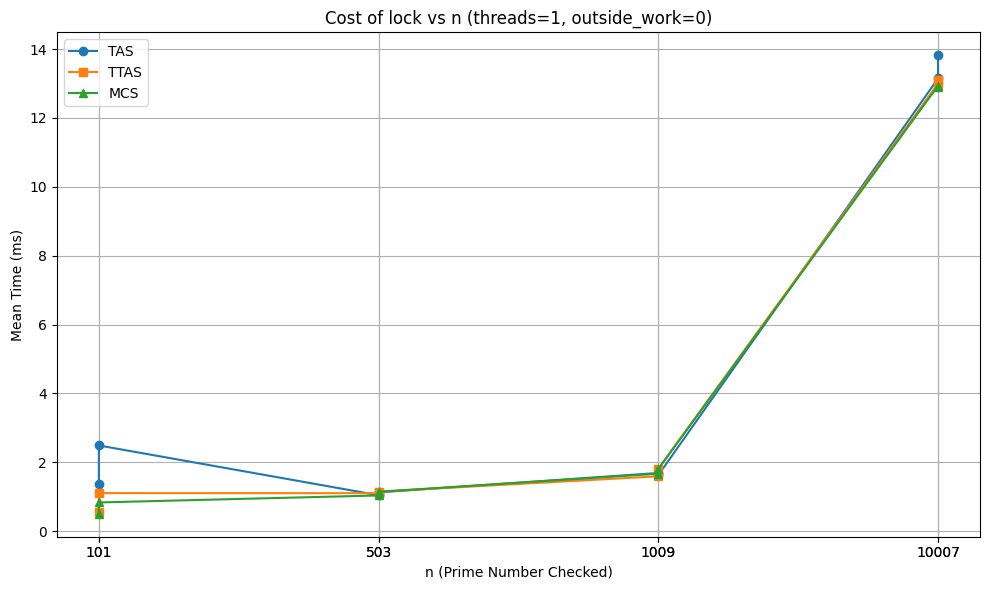

In [97]:
# Fix thread and outside_work to small values (e.g., threads=4, outside_work=0) to compare lock cost across n
fixed_threads = 1
fixed_outside_work = 0

df_lockcost = df[
    (df["threads"] == fixed_threads) &
    (df["outside_work"] == fixed_outside_work)
].sort_values("n")
df_lockcost["n"] = df_lockcost["n"].astype(str)

plt.figure(figsize=(10, 6))
plt.plot(df_lockcost["n"], df_lockcost["tas_ms"], marker='o', label="TAS")
plt.plot(df_lockcost["n"], df_lockcost["ttas_ms"], marker='s', label="TTAS")
plt.plot(df_lockcost["n"], df_lockcost["mcs_ms"], marker='^', label="MCS")

plt.title(f"Cost of lock vs n (threads={fixed_threads}, outside_work={fixed_outside_work})")
plt.xlabel("n (Prime Number Checked)")
plt.ylabel("Mean Time (ms)")
plt.xticks(df_lockcost["n"])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Performance and Scalability analysis

In [98]:
df = read_file("result.csv")

#### 1. Low thread + 0 outside work + low prime number
- Baseline overhead of each lock with no outside noise.

In [99]:
# fixed_n = 1009  # one of the low primes used in your data
# fixed_outside_work = 2

# # Filter and group, then compute the mean for each lock at every thread count
# df_scalability = df[
#     (df["outside_work"] <= fixed_outside_work)
# ].groupby("threads")[["tas_ms", "ttas_ms", "mcs_ms"]].mean().reset_index().sort_values("threads")

# plt.figure(figsize=(10, 6))
# plt.plot(df_scalability["threads"], df_scalability["tas_ms"], marker='o', label="TAS")
# plt.plot(df_scalability["threads"], df_scalability["ttas_ms"], marker='s', label="TTAS")
# plt.plot(df_scalability["threads"], df_scalability["mcs_ms"], marker='^', label="MCS")

# plt.title(f"Mean Execution Time vs Thread Count (n<={fixed_n}, outside work<={fixed_outside_work})")
# plt.xlabel("Thread Count")
# plt.ylabel("Mean Time (ms)")
# plt.legend()
# plt.grid(True)
# plt.show()

#### 2. High thread + 0 outside work + low prime number
- The MCS "Win": Max contention and high traffic.

#### 3. Low thread + 0 outside work + High prime number
- Does a long CS make the lock type less relevant?

#### 4.High thread + 0 outside work + High prime number
- 

#### 5. Low thread + 5 outside work + Low prime number
- Scenario where TAS might beat MCS due to lower overhead.

#### 6. High thread + 5 outside work + Low prime number
- Does the interconnect still choke even with outside work?

#### 7. Low thread + 5 outside work + High prime number
- Low-load baseline for long-running critical sections.

#### 8. High thread + 5 outside work + High prime number
- Scalability test under "realistic" staggered arrival rates.

### Experiment Analysis

#### 1. Scalability:
- How the performance changes with different thread count

ValueError: x and y must have same first dimension, but have shapes (6,) and (0,)

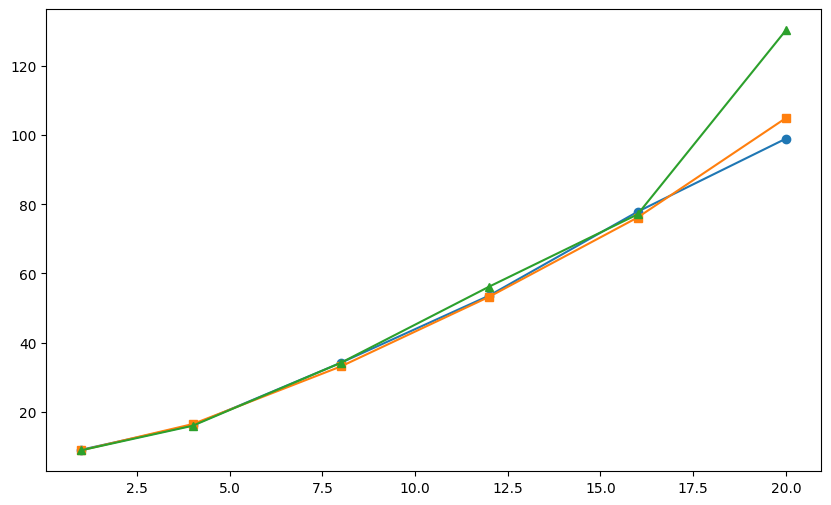

In [100]:
fixed_n = 101  # one of the low primes used in your data
fixed_outside_work = 1

# Group by thread count and compute mean execution time for each lock
# df_scalability = df[
#     (df["n"] == fixed_n) &
#     (df["outside_work"] == fixed_outside_work)
# ]
df_scalability = df


# Prepare exponential backoff data for plotting
# expbackoff_scalability = df_with_exponential_backoff[
#     (df_with_exponential_backoff["n"] == fixed_n) &
#     (df_with_exponential_backoff["outside_work"] == fixed_outside_work)
# ]
expbackoff_scalability = df_with_exponential_backoff

###############

df_scalability = df_scalability.groupby("threads", as_index=False)[["tas_ms", "ttas_ms", "mcs_ms"]].mean().sort_values("threads")

plt.figure(figsize=(10, 6))
plt.plot(df_scalability["threads"], df_scalability["tas_ms"], marker='o', label="TAS")
plt.plot(df_scalability["threads"], df_scalability["ttas_ms"], marker='s', label="TTAS")
plt.plot(df_scalability["threads"], df_scalability["mcs_ms"], marker='^', label="MCS")

expbackoff_scalability = expbackoff_scalability.groupby("threads", as_index=False)[["tas_ms", "ttas_ms"]].mean().sort_values("threads")

# Plot TAS exp backoff with same color/marker and dashed line
plt.plot(
    df_scalability["threads"],
    expbackoff_scalability["tas_ms"],
    marker='o',
    linestyle='--',
    color=plt.gca().lines[0].get_color(),
    label="TAS (exp backoff)"
)

# Plot TTAS exp backoff with same color/marker and dashed line
plt.plot(
    df_scalability["threads"],
    expbackoff_scalability["ttas_ms"],
    marker='s',
    linestyle='--',
    color=plt.gca().lines[1].get_color(),
    label="TTAS (exp backoff)"
)



plt.title(f"Mean Execution Time vs Thread Count (n={fixed_n}, outside work={fixed_outside_work})")
plt.xlabel("Thread Count")
plt.ylabel("Mean Time (ms)")
plt.legend()
plt.grid(True)
plt.show()

#### 2. Contention
- How the performance changes with different outside work? (Sensitivity to arrival)

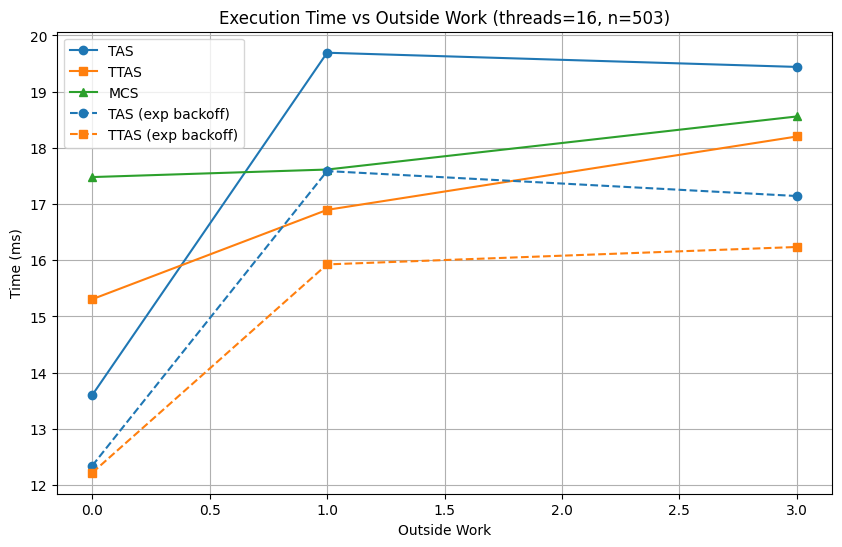

In [ ]:
# Analyze contention: performance vs. outside_work at fixed thread count and n

fixed_threads = 16  # choose a representative thread count present in your data, e.g., 8
fixed_n = 503    # keep n same as above for consistency

# Group by thread count and compute mean execution time for each lock
df_contention = df[
    (df["threads"] == fixed_threads) &
    (df["n"] == fixed_n)
]
# df_contention = df


expbackoff_contention = df_with_exponential_backoff[
    (df_with_exponential_backoff["threads"] == fixed_threads) &
    (df_with_exponential_backoff["n"] == fixed_n)
]
# expbackoff_contention = df_with_exponential_backoff

##########

df_contention = df_contention.groupby("outside_work", as_index=False)[["tas_ms", "ttas_ms", "mcs_ms"]].mean().sort_values("outside_work")

plt.figure(figsize=(10, 6))
plt.plot(df_contention["outside_work"], df_contention["tas_ms"], marker='o', label="TAS")
plt.plot(df_contention["outside_work"], df_contention["ttas_ms"], marker='s', label="TTAS")
plt.plot(df_contention["outside_work"], df_contention["mcs_ms"], marker='^', label="MCS")

# Also plot exp backoff variant for TAS and TTAS for comparison

expbackoff_contention = expbackoff_contention.groupby("outside_work", as_index=False)[["tas_ms", "ttas_ms"]].mean().sort_values("outside_work")

# Plot TAS exp backoff with same color/marker and dashed line
plt.plot(
    df_contention["outside_work"],
    expbackoff_contention["tas_ms"],
    marker='o',
    linestyle='--',
    color=plt.gca().lines[0].get_color(),
    label="TAS (exp backoff)"
)

# Plot TTAS exp backoff with same color/marker and dashed line
plt.plot(
    df_contention["outside_work"],
    expbackoff_contention["ttas_ms"],
    marker='s',
    linestyle='--',
    color=plt.gca().lines[1].get_color(),
    label="TTAS (exp backoff)"
)


plt.title(f"Execution Time vs Outside Work (threads={fixed_threads}, n={fixed_n})")
plt.xlabel("Outside Work")
plt.ylabel("Time (ms)")
plt.legend()
plt.grid(True)
plt.show()

#### 3. Workload
- How the overall performance changes with different the critical section workload?

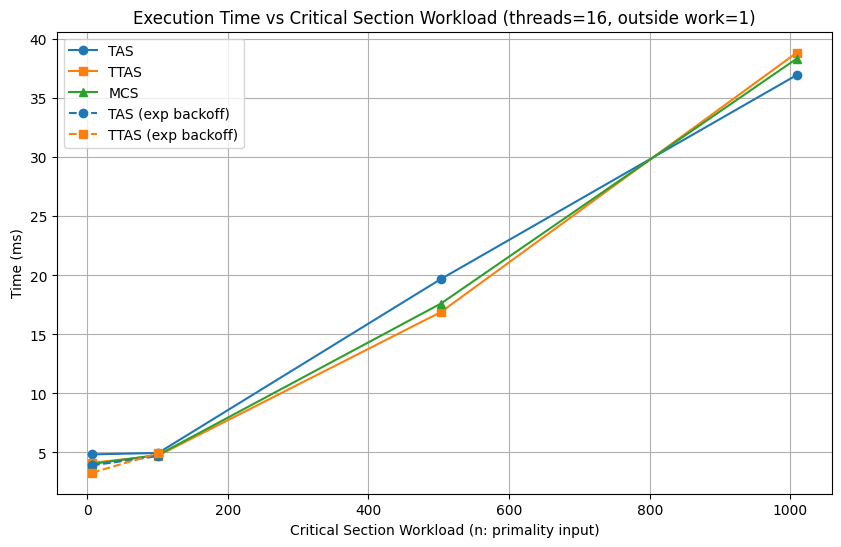

In [ ]:
# Analyze workload: performance vs. n (the "critical section workload") at fixed thread count and outside_work

fixed_threads = 16  # keep consistent with earlier analysis
fixed_outside_work = 1  # minimal outside work to isolate impact of prime complexity

df_workload = df[
    (df["threads"] == fixed_threads) &
    (df["outside_work"] == fixed_outside_work) &
    (df["n"] <= 1009)
].groupby("n", as_index=False)[["tas_ms", "ttas_ms", "mcs_ms"]].mean().sort_values("n")

plt.figure(figsize=(10, 6))
plt.plot(df_workload["n"], df_workload["tas_ms"], marker='o', label="TAS")
plt.plot(df_workload["n"], df_workload["ttas_ms"], marker='s', label="TTAS")
plt.plot(df_workload["n"], df_workload["mcs_ms"], marker='^', label="MCS")

# Plot exponential backoff results for workload as a dashed line with the same color mapping
expbackoff_workload = df_with_exponential_backoff[
    (df_with_exponential_backoff["threads"] == fixed_threads) &
    (df_with_exponential_backoff["outside_work"] == fixed_outside_work) &
    (df_with_exponential_backoff["n"] <= 101)
].groupby("n", as_index=False)[["tas_ms", "ttas_ms"]].mean().sort_values("n")

# Match colors to the existing TAS and TTAS lines
plt.plot(
    expbackoff_workload["n"],
    expbackoff_workload["tas_ms"],
    marker='o',
    linestyle='--',
    color=plt.gca().lines[0].get_color(),
    label="TAS (exp backoff)"
)
plt.plot(
    expbackoff_workload["n"],
    expbackoff_workload["ttas_ms"],
    marker='s',
    linestyle='--',
    color=plt.gca().lines[1].get_color(),
    label="TTAS (exp backoff)"
)


plt.title(f"Execution Time vs Critical Section Workload (threads={fixed_threads}, outside work={fixed_outside_work})")
plt.xlabel("Critical Section Workload (n: primality input)")
plt.ylabel("Time (ms)")
plt.legend()
plt.grid(True)
plt.show()